Dataset Loaded Successfully
Dataset Shape: (23490, 13)

Numerical Columns:
['age', 'length_of_service', 'avg_training_score', 'previous_year_rating']

Applying: StandardScaler
StandardScaler.csv saved successfully.

Applying: MinMaxScaler
MinMaxScaler.csv saved successfully.

Applying: RobustScaler
RobustScaler.csv saved successfully.

Applying: MaxAbsScaler
MaxAbsScaler.csv saved successfully.


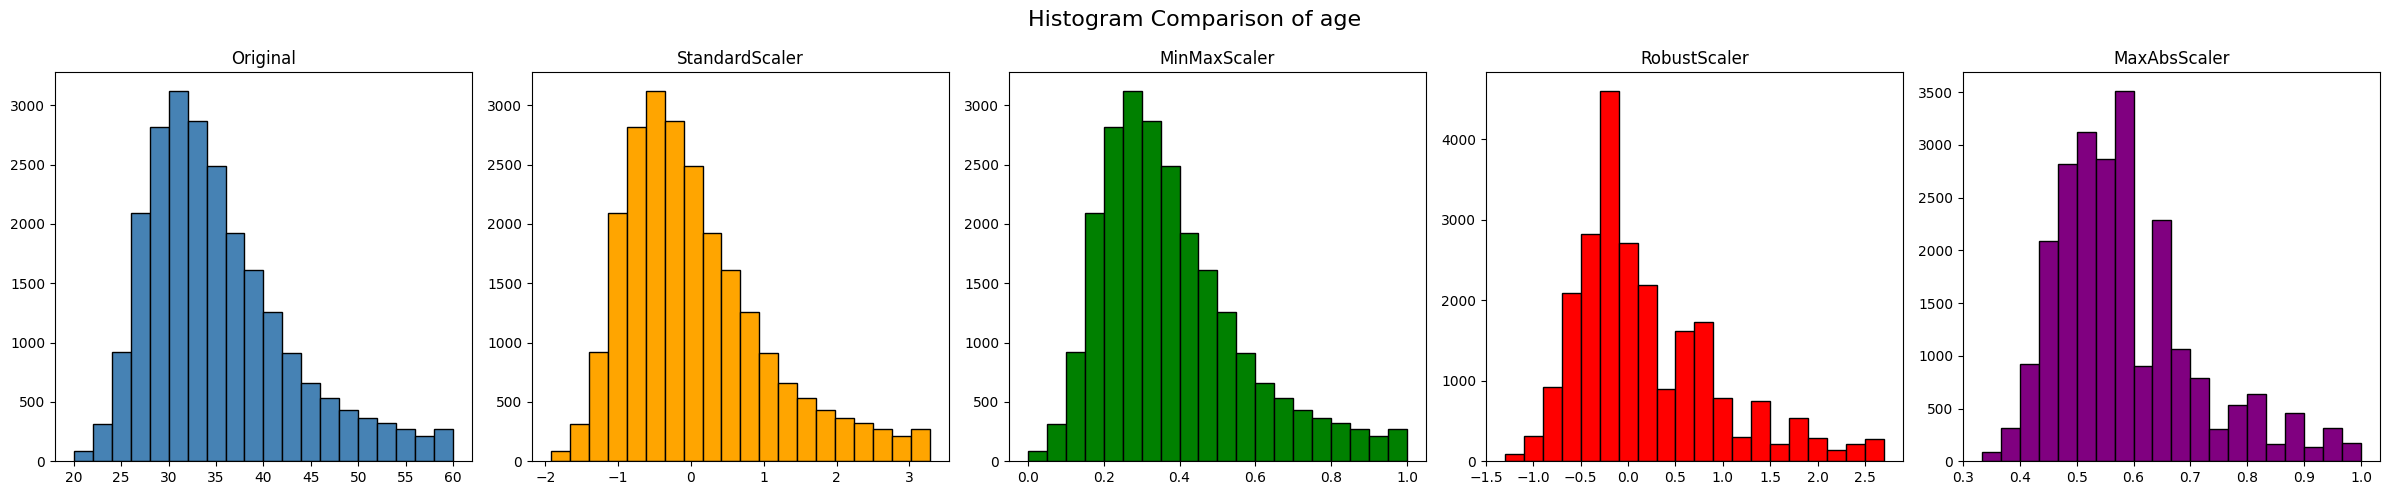

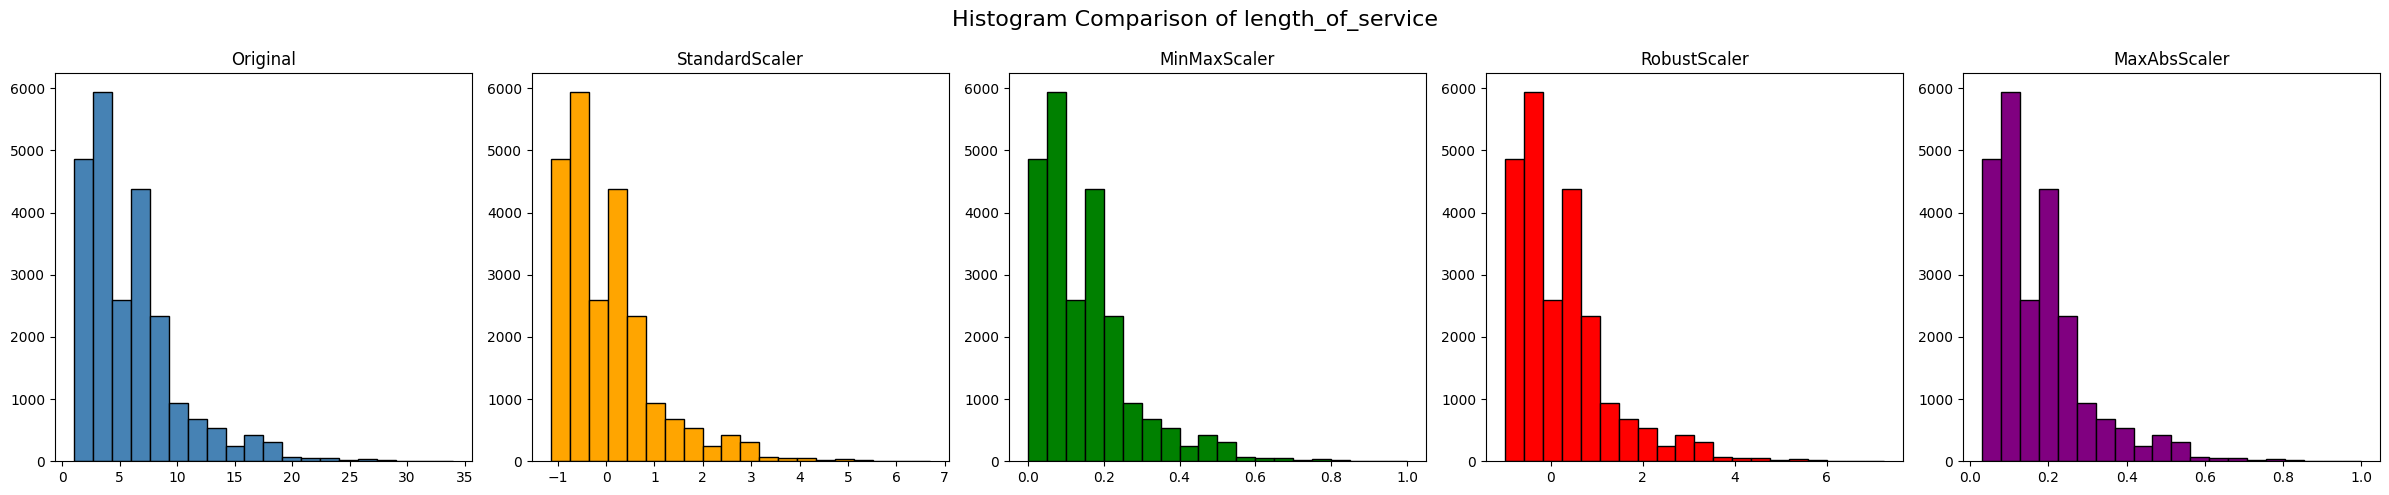

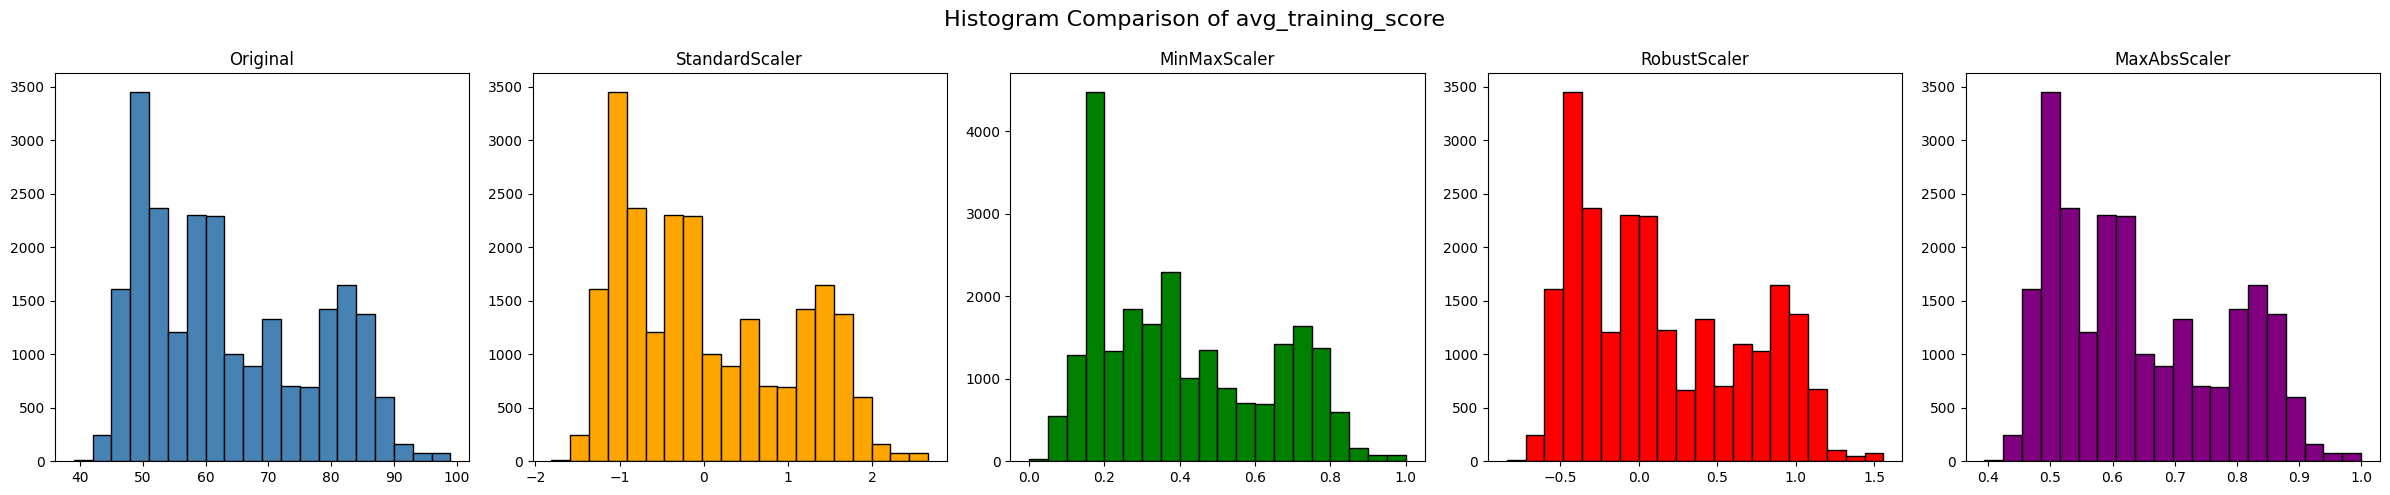

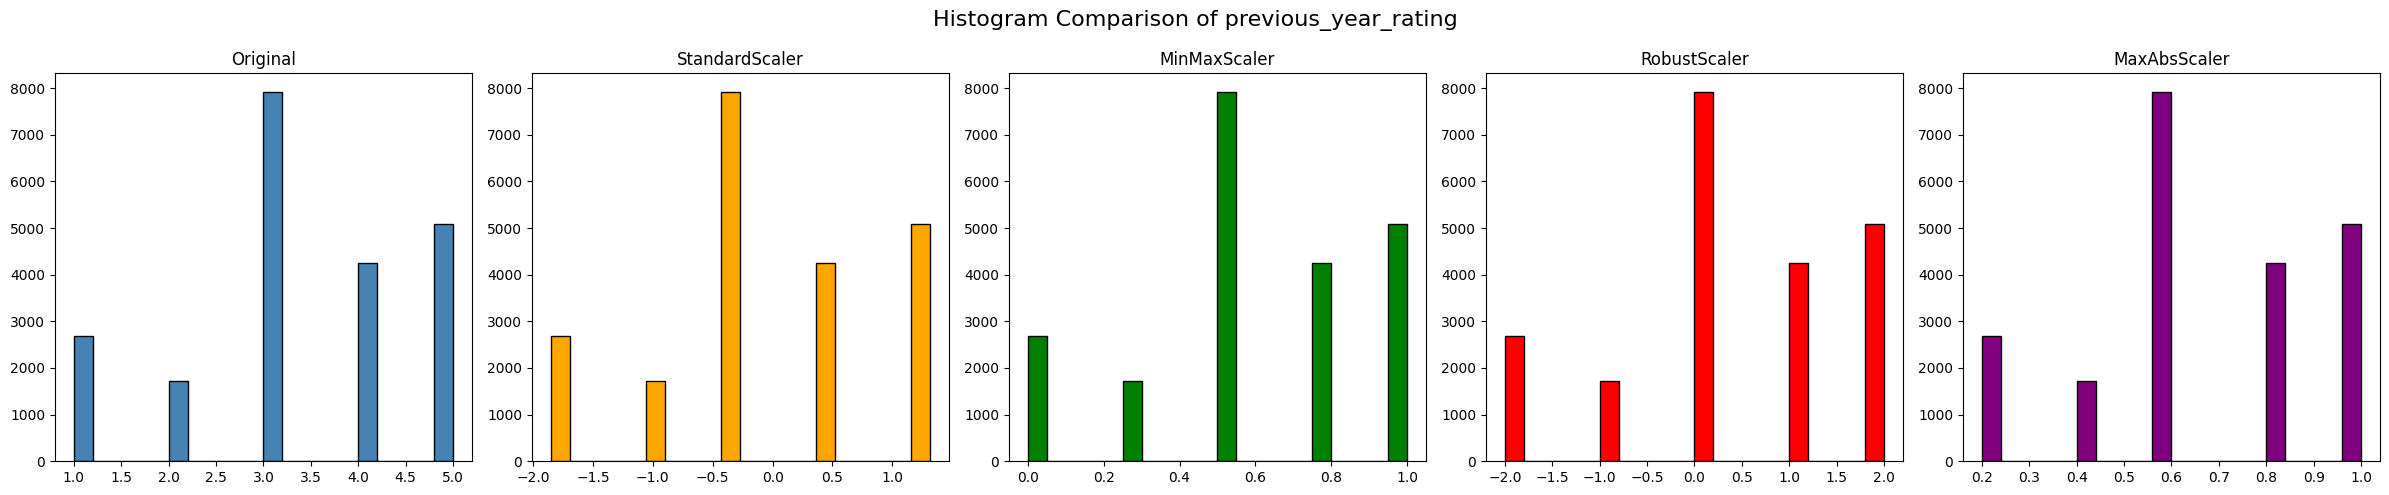


All Histograms Saved Successfully!


In [1]:
# ==========================================================
# HR Analytics - Data Scaling using Different Scalers
# ==========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import os

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    MaxAbsScaler
)

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------

df = pd.read_csv("Test_data.csv")

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

# ----------------------------------------------------------
# Select Numerical Columns
# ----------------------------------------------------------

numerical_columns = [
    'age',
    'length_of_service',
    'avg_training_score',
    'previous_year_rating'
]

print("\nNumerical Columns:")
print(numerical_columns)

# ----------------------------------------------------------
# Create Output Folders
# ----------------------------------------------------------

os.makedirs("Scaled_Datasets", exist_ok=True)
os.makedirs("Scaling_Histograms", exist_ok=True)

# ----------------------------------------------------------
# Function to Apply Scaler
# ----------------------------------------------------------

def apply_scaler(dataset, scaler_name):

    scalers = {
        "StandardScaler": StandardScaler(),
        "MinMaxScaler": MinMaxScaler(),
        "RobustScaler": RobustScaler(),
        "MaxAbsScaler": MaxAbsScaler()
    }

    scaler = scalers[scaler_name]

    scaled_dataset = dataset.copy()

    scaled_dataset[numerical_columns] = scaler.fit_transform(
        scaled_dataset[numerical_columns]
    )

    return scaled_dataset

# ----------------------------------------------------------
# Apply All Scalers
# ----------------------------------------------------------

scaler_names = [
    "StandardScaler",
    "MinMaxScaler",
    "RobustScaler",
    "MaxAbsScaler"
]

scaled_datasets = {}

for scaler in scaler_names:

    print("\nApplying:", scaler)

    scaled_df = apply_scaler(df, scaler)

    scaled_datasets[scaler] = scaled_df

    # Save Dataset
    scaled_df.to_csv(
        f"Scaled_Datasets/{scaler}.csv",
        index=False
    )

    print(f"{scaler}.csv saved successfully.")

# ----------------------------------------------------------
# Histogram Comparison
# ----------------------------------------------------------

for column in numerical_columns:

    fig, axes = plt.subplots(1,5, figsize=(24,5))

    # Original
    axes[0].hist(
        df[column].dropna(),
        bins=20,
        color='steelblue',
        edgecolor='black'
    )
    axes[0].set_title("Original")

    # StandardScaler
    axes[1].hist(
        scaled_datasets["StandardScaler"][column].dropna(),
        bins=20,
        color='orange',
        edgecolor='black'
    )
    axes[1].set_title("StandardScaler")

    # MinMaxScaler
    axes[2].hist(
        scaled_datasets["MinMaxScaler"][column].dropna(),
        bins=20,
        color='green',
        edgecolor='black'
    )
    axes[2].set_title("MinMaxScaler")

    # RobustScaler
    axes[3].hist(
        scaled_datasets["RobustScaler"][column].dropna(),
        bins=20,
        color='red',
        edgecolor='black'
    )
    axes[3].set_title("RobustScaler")

    # MaxAbsScaler
    axes[4].hist(
        scaled_datasets["MaxAbsScaler"][column].dropna(),
        bins=20,
        color='purple',
        edgecolor='black'
    )
    axes[4].set_title("MaxAbsScaler")

    plt.suptitle(f"Histogram Comparison of {column}", fontsize=16)

    plt.tight_layout()

    # Save Histogram
    plt.savefig(
        f"Scaling_Histograms/{column}_Histogram.png",
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

print("\nAll Histograms Saved Successfully!")

In [4]:
# ==========================================================
# HR Analytics - ML Model for Binary Classification Problem
# ==========================================================


import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report

from sklearn.preprocessing import LabelEncoder

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Load Dataset
df = pd.read_csv("Train.csv")

# Fill Missing Values
df['previous_year_rating'] = df['previous_year_rating'].fillna(3)

# Encode Categorical Columns

categorical_cols = df.select_dtypes(include='object').columns

le = LabelEncoder()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Features & Target

X = df.drop("is_promoted",axis=1)

y = df["is_promoted"]

# Train-Test Split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

models = {

    "XGBoost":XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),

    "CatBoost":CatBoostClassifier(
        verbose=0,
        random_state=42
    ),

    "LightGBM":LGBMClassifier(
        random_state=42
    )

}

for name,model in models.items():

    print("="*60)

    print(name)

    print("="*60)

    model.fit(X_train,y_train)

    prediction=model.predict(X_test)

    accuracy=accuracy_score(y_test,prediction)

    print("Accuracy :",round(accuracy*100,2),"%")

    print(classification_report(y_test,prediction))

XGBoost
Accuracy : 77.5 %
              precision    recall  f1-score   support

           0       0.81      0.86      0.83      3037
           1       0.71      0.62      0.66      1661

    accuracy                           0.78      4698
   macro avg       0.76      0.74      0.75      4698
weighted avg       0.77      0.78      0.77      4698

CatBoost
Accuracy : 78.71 %
              precision    recall  f1-score   support

           0       0.81      0.87      0.84      3037
           1       0.73      0.64      0.68      1661

    accuracy                           0.79      4698
   macro avg       0.77      0.75      0.76      4698
weighted avg       0.78      0.79      0.78      4698

LightGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6523, number of negative: 12269
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001107 seconds.
You can set `force_row_wise=t

XGBoost + StandardScaler
Accuracy : 77.86 %


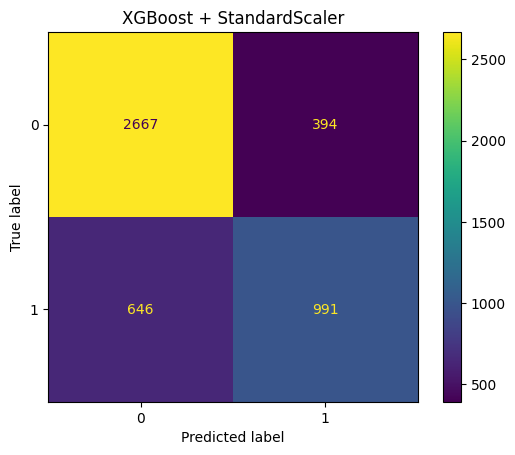

CatBoost + StandardScaler
Accuracy : 79.12 %


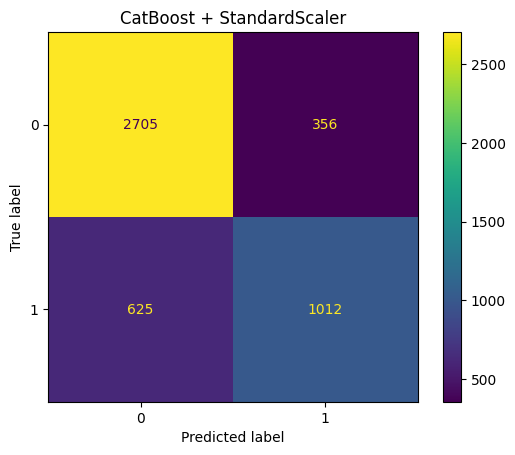

LightGBM + StandardScaler
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6547, number of negative: 12245
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 462
[LightGBM] [Info] Number of data points in the train set: 18792, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348393 -> initscore=-0.626111
[LightGBM] [Info] Start training from score -0.626111
Accuracy : 79.16 %


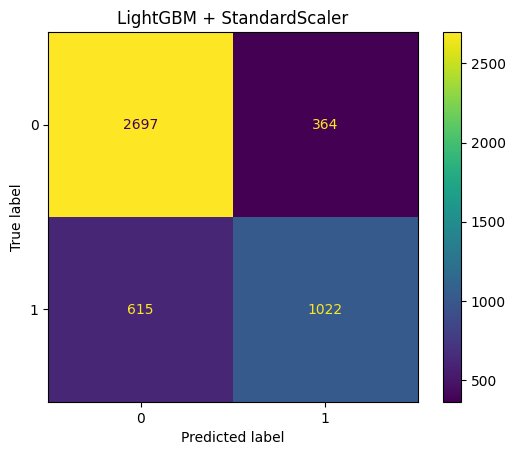

XGBoost + MinMaxScaler
Accuracy : 77.86 %


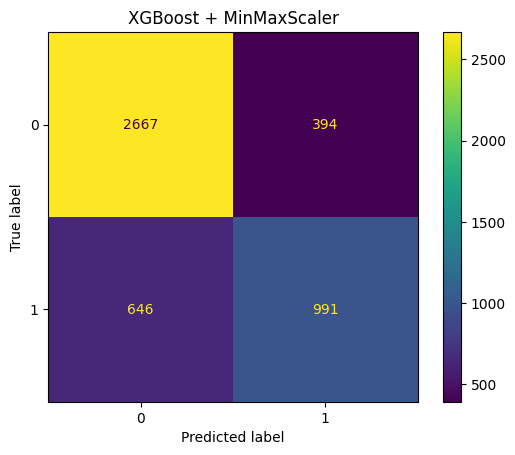

CatBoost + MinMaxScaler
Accuracy : 79.12 %


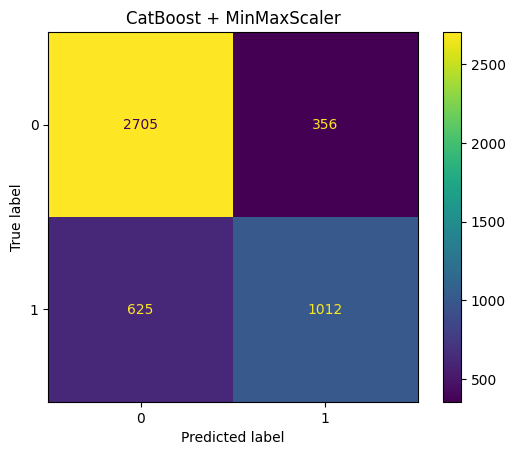

LightGBM + MinMaxScaler
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6547, number of negative: 12245
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002764 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 457
[LightGBM] [Info] Number of data points in the train set: 18792, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348393 -> initscore=-0.626111
[LightGBM] [Info] Start training from score -0.626111
Accuracy : 79.16 %


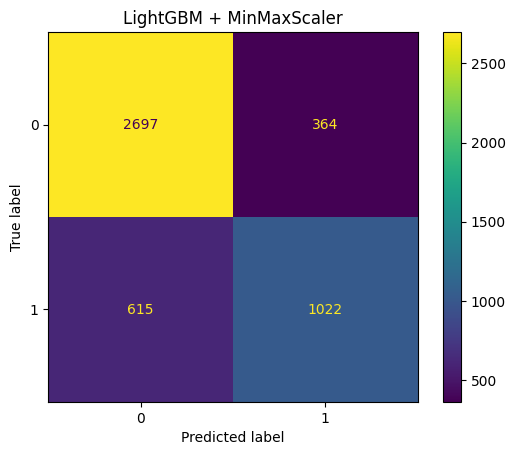

XGBoost + RobustScaler
Accuracy : 77.86 %


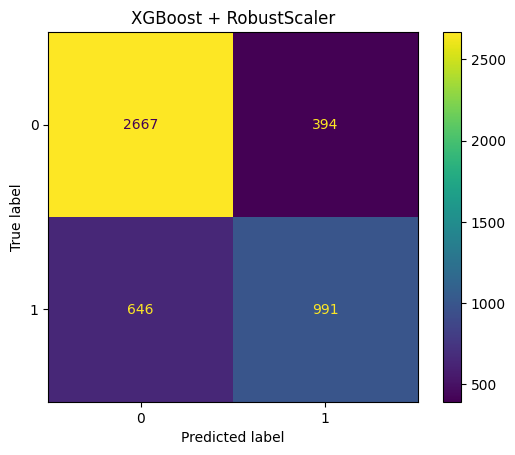

CatBoost + RobustScaler
Accuracy : 79.12 %


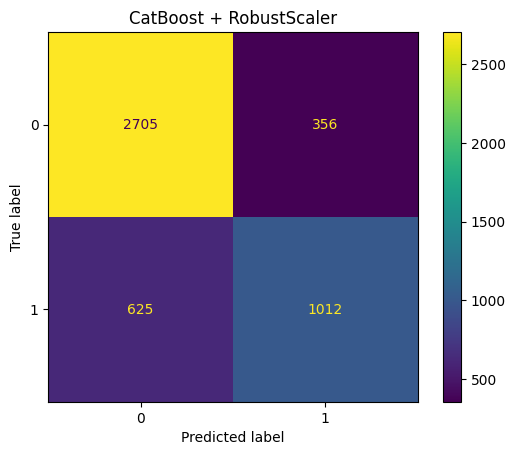

LightGBM + RobustScaler
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6547, number of negative: 12245
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 457
[LightGBM] [Info] Number of data points in the train set: 18792, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348393 -> initscore=-0.626111
[LightGBM] [Info] Start training from score -0.626111
Accuracy : 79.16 %


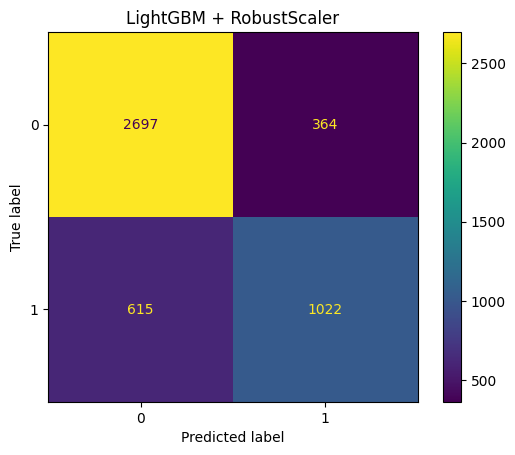

XGBoost + MaxAbsScaler
Accuracy : 77.86 %


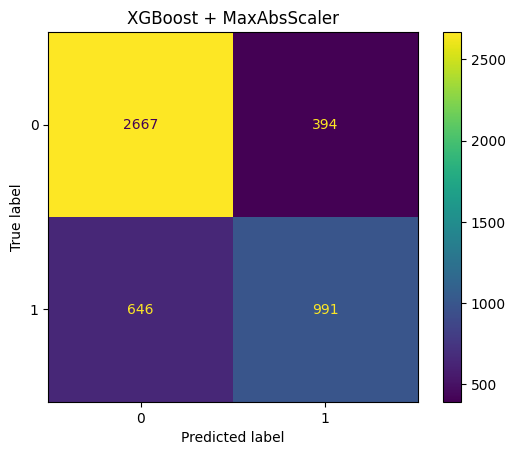

CatBoost + MaxAbsScaler
Accuracy : 79.12 %


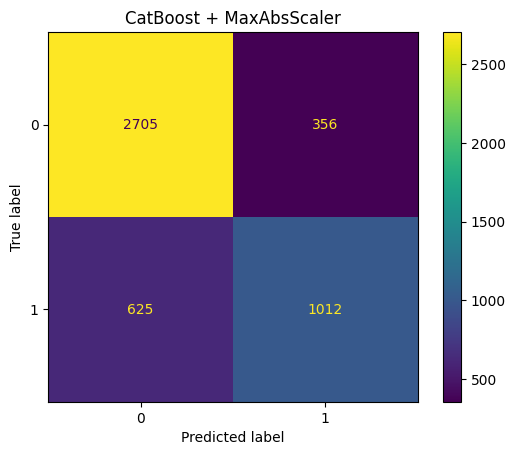

LightGBM + MaxAbsScaler
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 6547, number of negative: 12245
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005271 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 462
[LightGBM] [Info] Number of data points in the train set: 18792, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.348393 -> initscore=-0.626111
[LightGBM] [Info] Start training from score -0.626111
Accuracy : 79.16 %


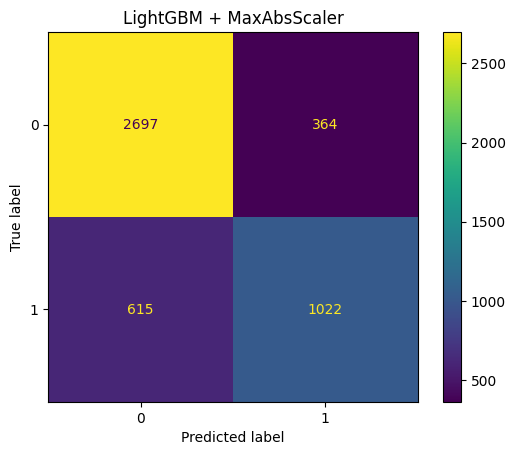

            Scaler     Model  Accuracy
2   StandardScaler  LightGBM     79.16
11    MaxAbsScaler  LightGBM     79.16
8     RobustScaler  LightGBM     79.16
5     MinMaxScaler  LightGBM     79.16
10    MaxAbsScaler  CatBoost     79.12
7     RobustScaler  CatBoost     79.12
1   StandardScaler  CatBoost     79.12
4     MinMaxScaler  CatBoost     79.12
3     MinMaxScaler   XGBoost     77.86
0   StandardScaler   XGBoost     77.86
6     RobustScaler   XGBoost     77.86
9     MaxAbsScaler   XGBoost     77.86
Results Saved Successfully.


In [3]:
# ==========================================================
# HR Analytics - Report Results to check for various scalers and check which gives better accuracy.
# ==========================================================
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    MaxAbsScaler,
    LabelEncoder
)

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv("Train.csv")

# Fill Missing Values
df['previous_year_rating'] = df['previous_year_rating'].fillna(3)

# Encode Categorical Variables
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Features and Target
X = df.drop("is_promoted", axis=1)
y = df["is_promoted"]

# Numerical Columns
numerical_columns = [
    'age',
    'length_of_service',
    'avg_training_score',
    'previous_year_rating',
    'no_of_trainings'
]

# =====================================================
# Scaling Function
# =====================================================

def scale_data(X_train, X_test, scaler_name):

    scalers = {
        "StandardScaler": StandardScaler(),
        "MinMaxScaler": MinMaxScaler(),
        "RobustScaler": RobustScaler(),
        "MaxAbsScaler": MaxAbsScaler()
    }

    scaler = scalers[scaler_name]

    X_train = X_train.copy()
    X_test = X_test.copy()

    X_train[numerical_columns] = scaler.fit_transform(
        X_train[numerical_columns]
    )

    X_test[numerical_columns] = scaler.transform(
        X_test[numerical_columns]
    )

    return X_train, X_test

# =====================================================
# Train Test Split
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =====================================================
# Models
# =====================================================

models = {

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),

    "CatBoost": CatBoostClassifier(
        verbose=0,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        random_state=42
    )

}

scalers = [
    "StandardScaler",
    "MinMaxScaler",
    "RobustScaler",
    "MaxAbsScaler"
]

results = []

# =====================================================
# Run All Experiments
# =====================================================

for scaler in scalers:

    X_train_scaled, X_test_scaled = scale_data(
        X_train,
        X_test,
        scaler
    )

    for model_name, model in models.items():

        print("="*70)
        print(f"{model_name} + {scaler}")
        print("="*70)

        model.fit(X_train_scaled, y_train)

        prediction = model.predict(X_test_scaled)

        accuracy = accuracy_score(
            y_test,
            prediction
        )

        print("Accuracy :", round(accuracy*100,2), "%")

        results.append({
            "Scaler": scaler,
            "Model": model_name,
            "Accuracy": round(accuracy*100,2)
        })

        # Confusion Matrix
        cm = confusion_matrix(
            y_test,
            prediction
        )

        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm
        )

        disp.plot()

        plt.title(f"{model_name} + {scaler}")

        plt.show()

# =====================================================
# Results Table
# =====================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

print(results_df)

results_df.to_csv(
    "Model_Comparison.csv",
    index=False
)

print("Results Saved Successfully.")